# 03 — Archetype plots

All the standard figures from the saved pipeline outputs: endmember loadings,
abundance distributions, loading heatmap, reconstruction histograms, and the
noise-floor / abundance-weighted-relevance diagnostics.

Run `02_unmixing_pipeline.ipynb` or `python scripts/run_pipeline.py` first.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_config

sns.set_style('whitegrid')
config = load_config()

In [2]:
from src.data.loading import load_processed

endmembers, abundances_df, meta = load_processed(config)
arch_cols = list(endmembers.columns)
candidate_labels = list(endmembers.index)
M = endmembers.to_numpy()                      # (L candidates, p archetypes)
A = abundances_df[arch_cols].to_numpy().T      # (p archetypes, N precincts)
L, p = M.shape
print(f'{L} candidates, {p} archetypes, {A.shape[1]:,} precincts')

42 candidates, 6 archetypes, 92,486 precincts


## Endmember loadings — top candidates per archetype

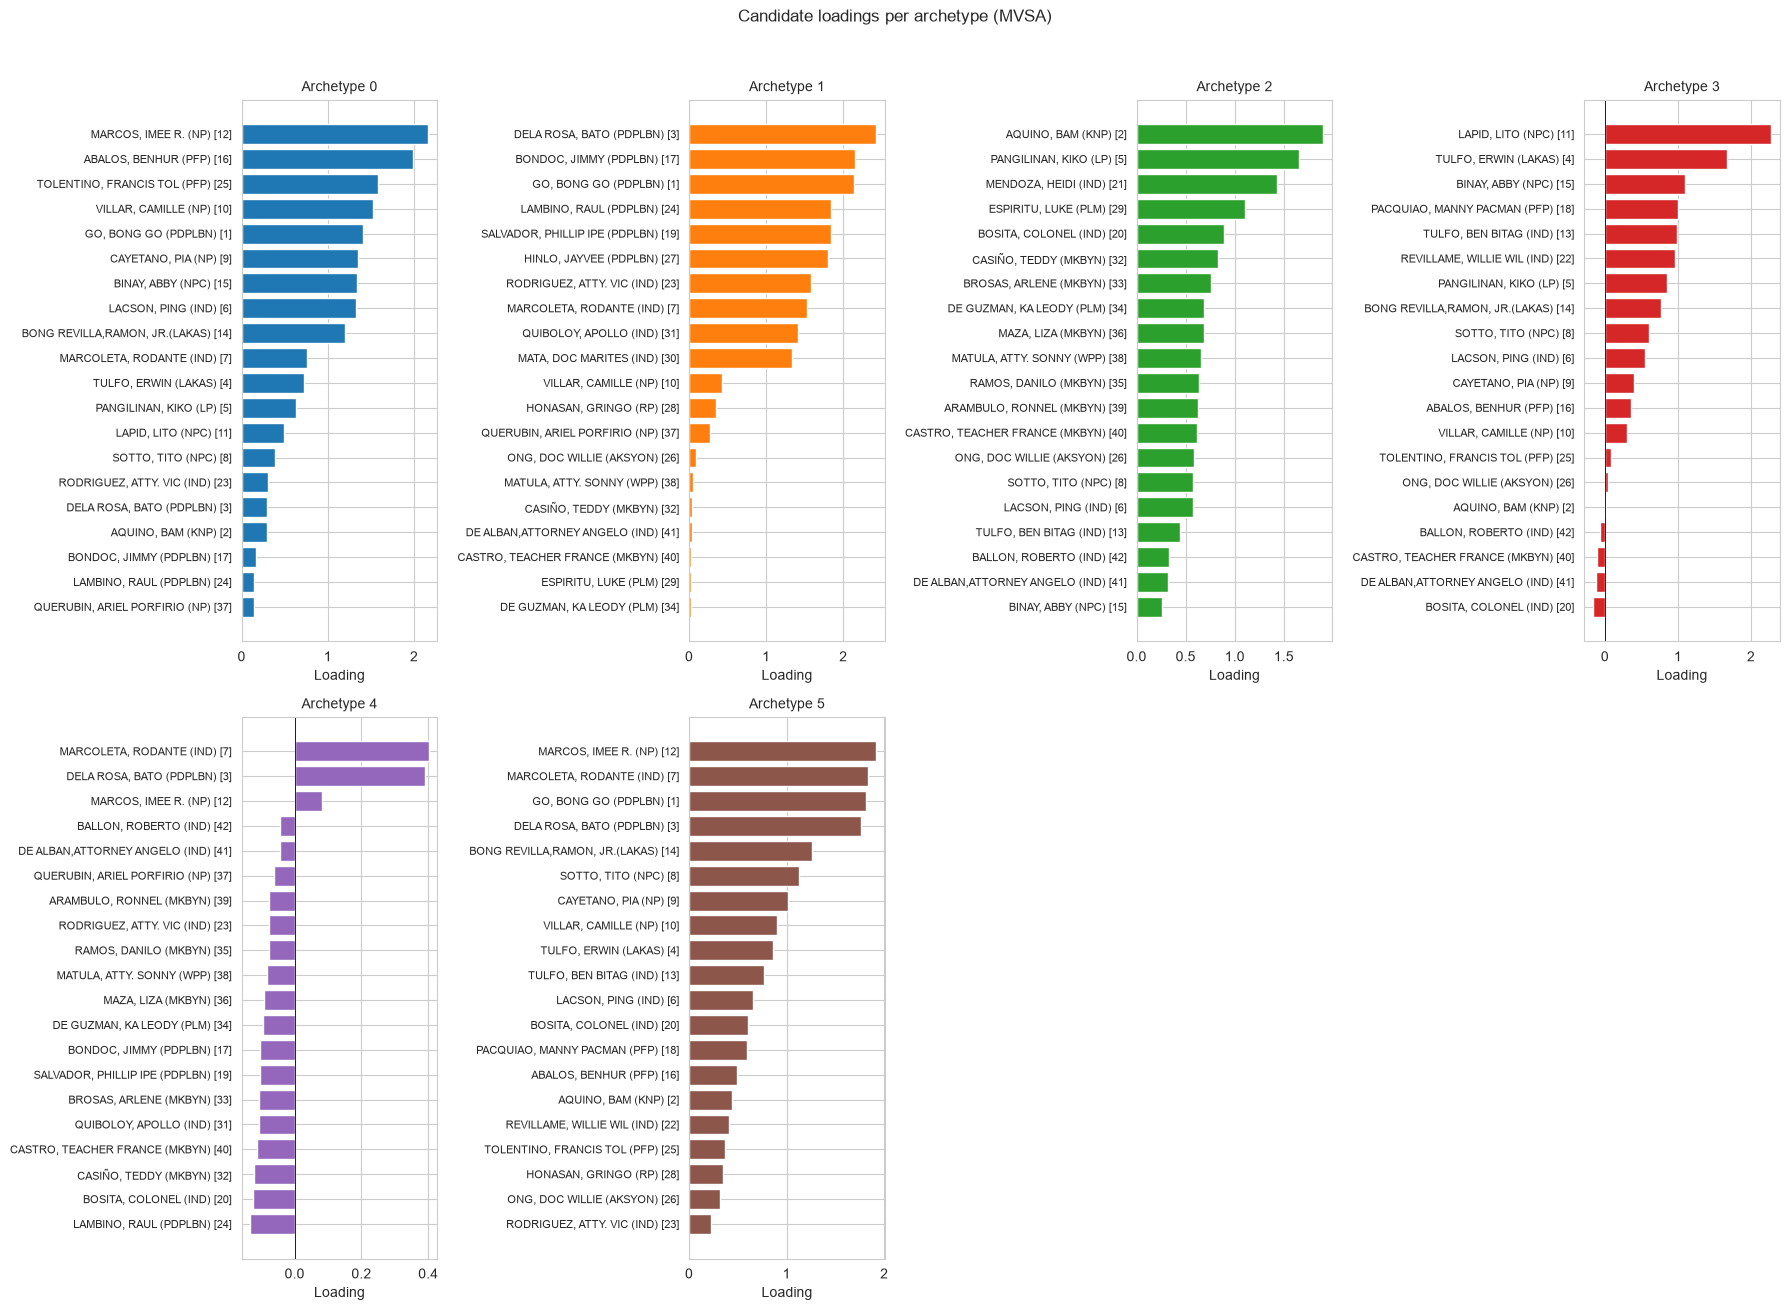

In [37]:
from src.figures import plot_archetypes_loadings_grid

plot_archetypes_loadings_grid(M, candidate_labels, top_n=20,
                              suptitle='Candidate loadings per archetype (MVSA)')

## Loadings vs. candidate rank (archetype spectra)

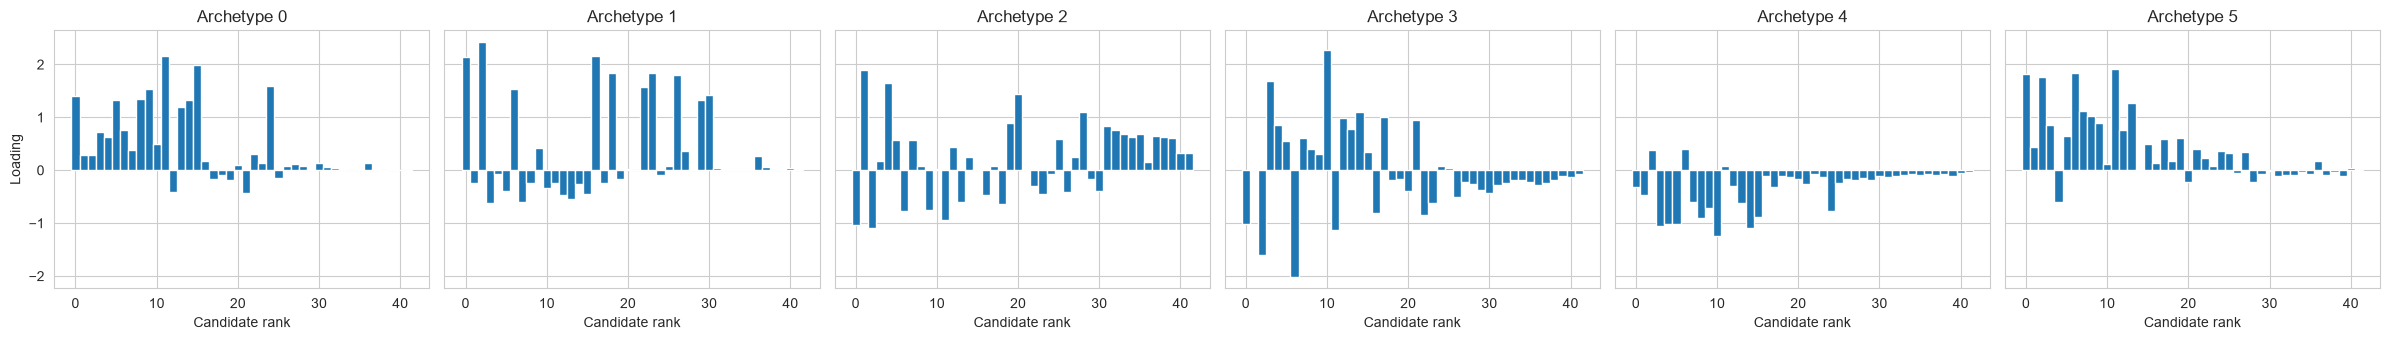

In [4]:
fig, axes = plt.subplots(1, p, figsize=(4 * p, 3.5), sharey=True)
for j, ax in enumerate(np.atleast_1d(axes)):
    ax.bar(range(L), M[:, j], color='C0', width=1.0)
    ax.set_xlabel('Candidate rank')
    ax.set_title(f'Archetype {j}')
np.atleast_1d(axes)[0].set_ylabel('Loading')
fig.tight_layout()

## Loading heatmap (candidates × archetypes)

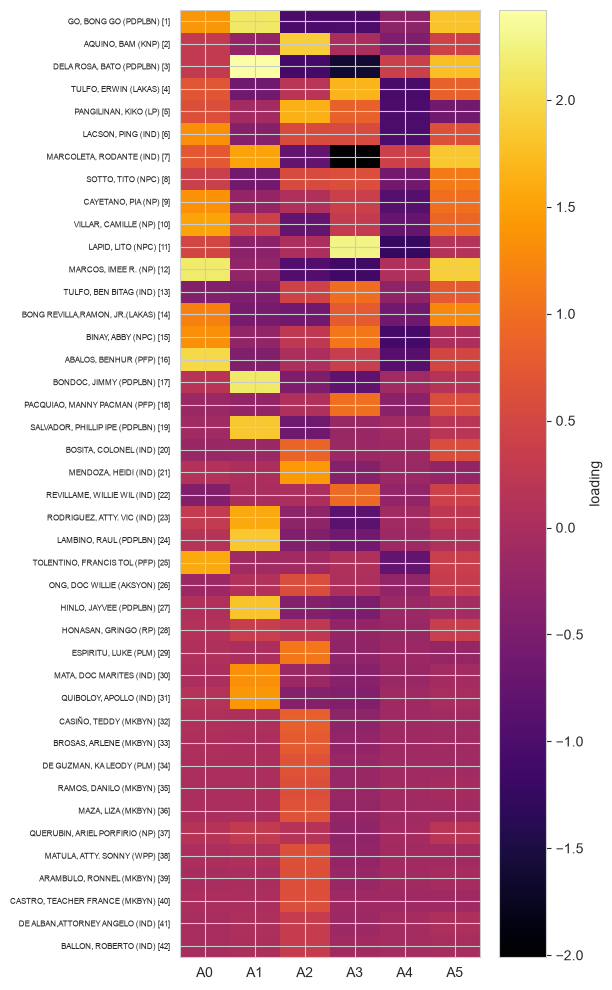

In [5]:
plt.figure(figsize=(6, 10))
plt.imshow(M, cmap='inferno', aspect='auto')
plt.yticks(ticks=np.arange(L), labels=candidate_labels, fontsize=6)
plt.xticks(ticks=np.arange(p), labels=[f'A{j}' for j in range(p)])
plt.colorbar(label='loading')
plt.tight_layout()

## Per-precinct abundance distributions

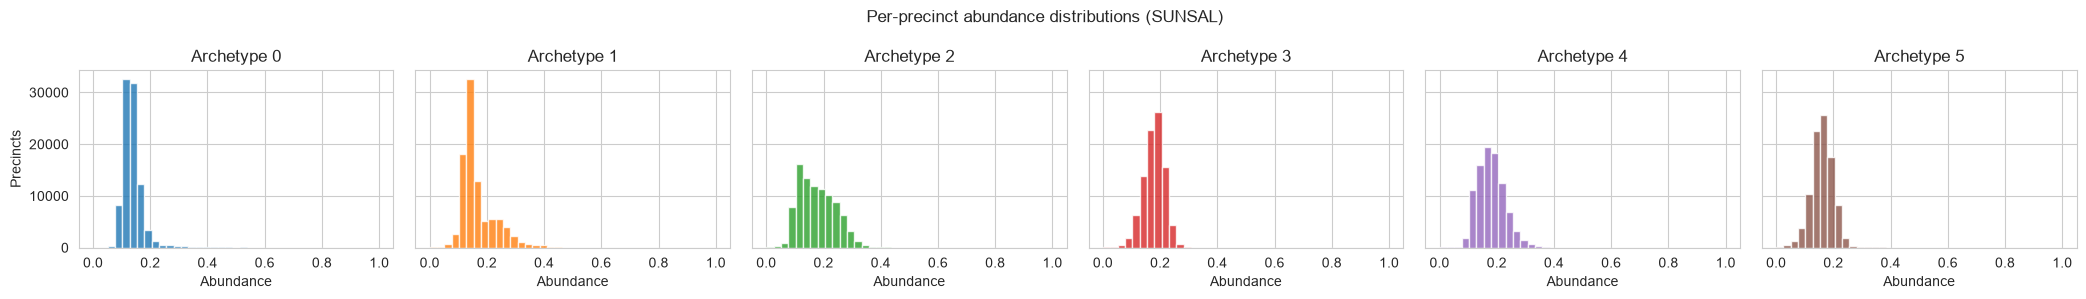

In [6]:
fig, axes = plt.subplots(1, p, figsize=(3.5 * p, 3), sharey=True)
bins = np.linspace(0, 1, 40)
for j, ax in enumerate(np.atleast_1d(axes)):
    ax.hist(A[j, :], bins=bins, color=f'C{j}', edgecolor='white', alpha=0.8)
    ax.set_xlabel('Abundance')
    ax.set_title(f'Archetype {j}')
np.atleast_1d(axes)[0].set_ylabel('Precincts')
fig.suptitle('Per-precinct abundance distributions (SUNSAL)')
fig.tight_layout()

## Reconstruction histograms

Needs the vote matrix — recompute the (fast) preprocessing step.

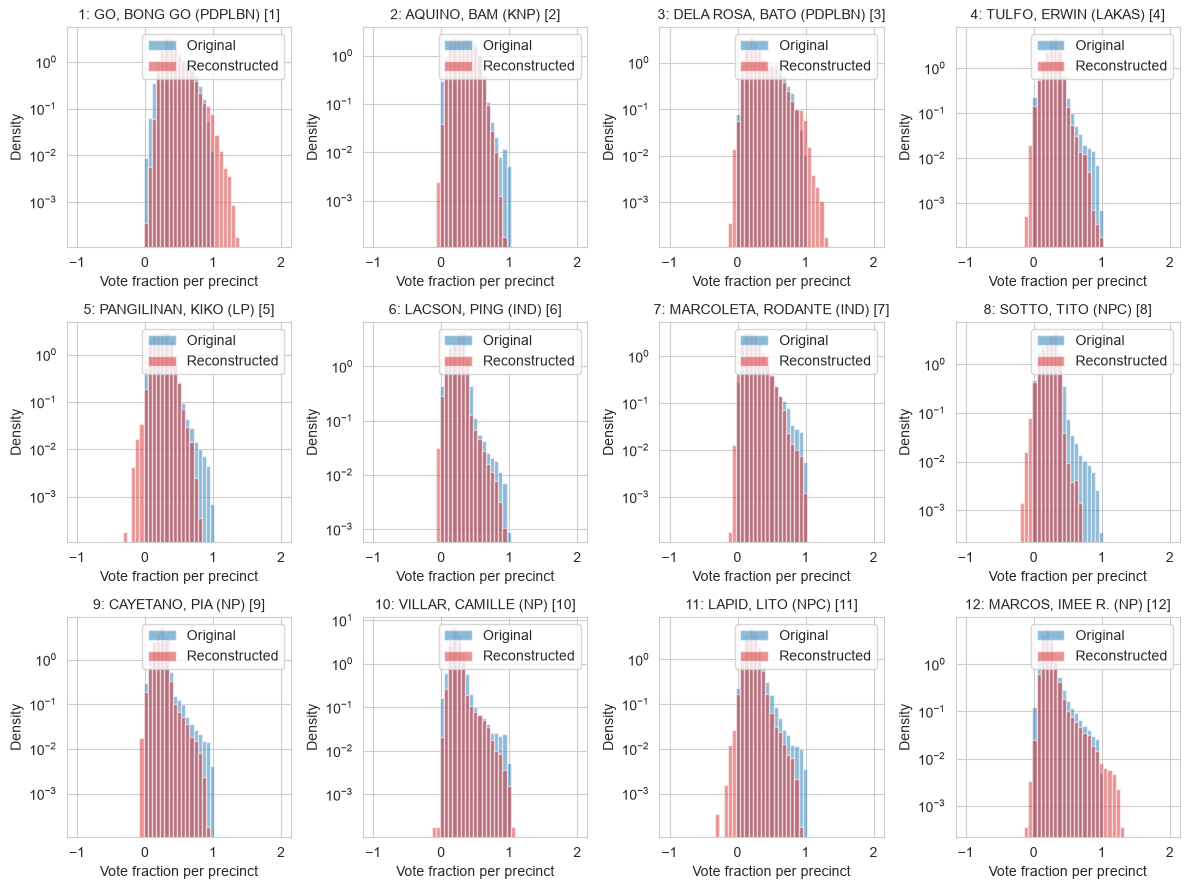

In [7]:
from src.data import load_complete
from src.data.preprocessing import preprocess_from_config
from src.figures import plot_reconstruction_histograms

df = load_complete(config)
pre = preprocess_from_config(df, config, verbose=False)
Y = pre.Y
Y_rec = M @ A

plot_reconstruction_histograms(
    Y, Y_rec,
    top_n_index=list(range(12)),          # rows already rank-ordered
    top_n_names=candidate_labels[:12])

## Noise floor + abundance-weighted candidate relevance

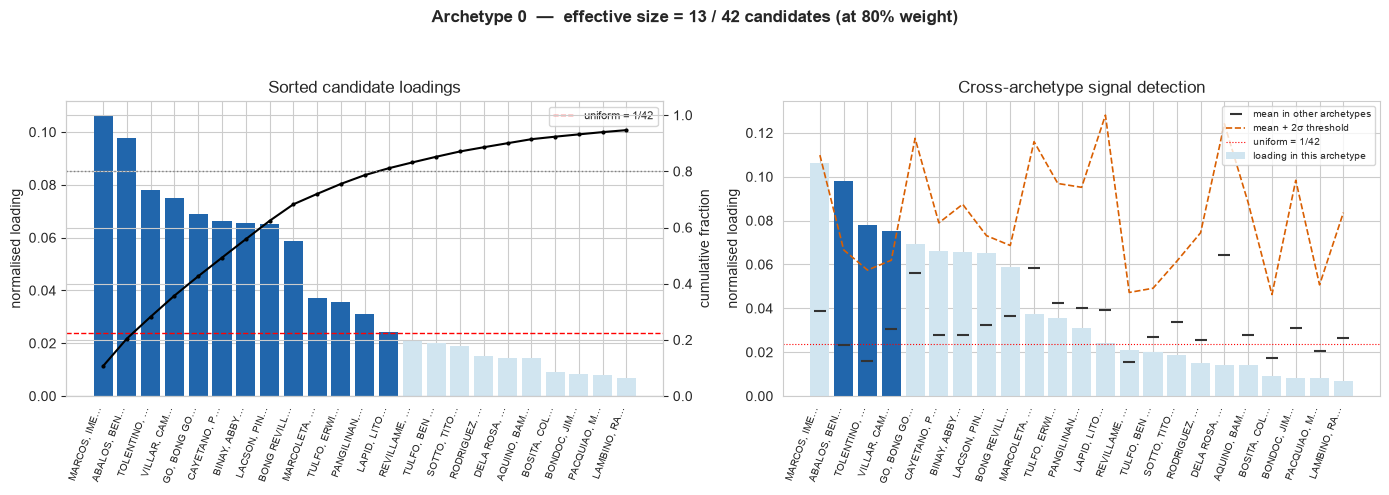

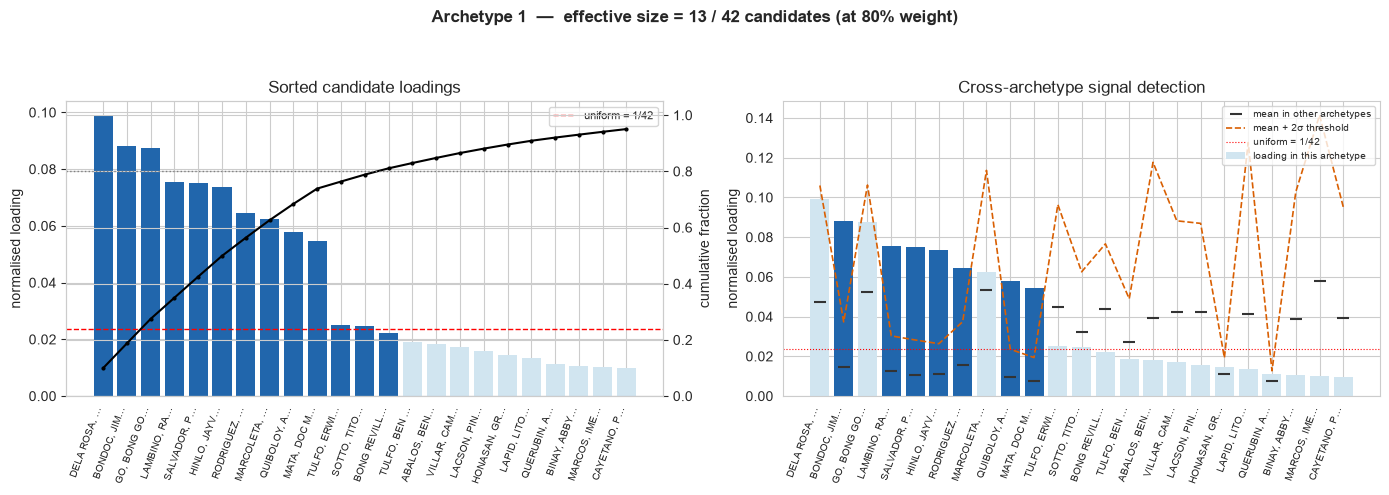

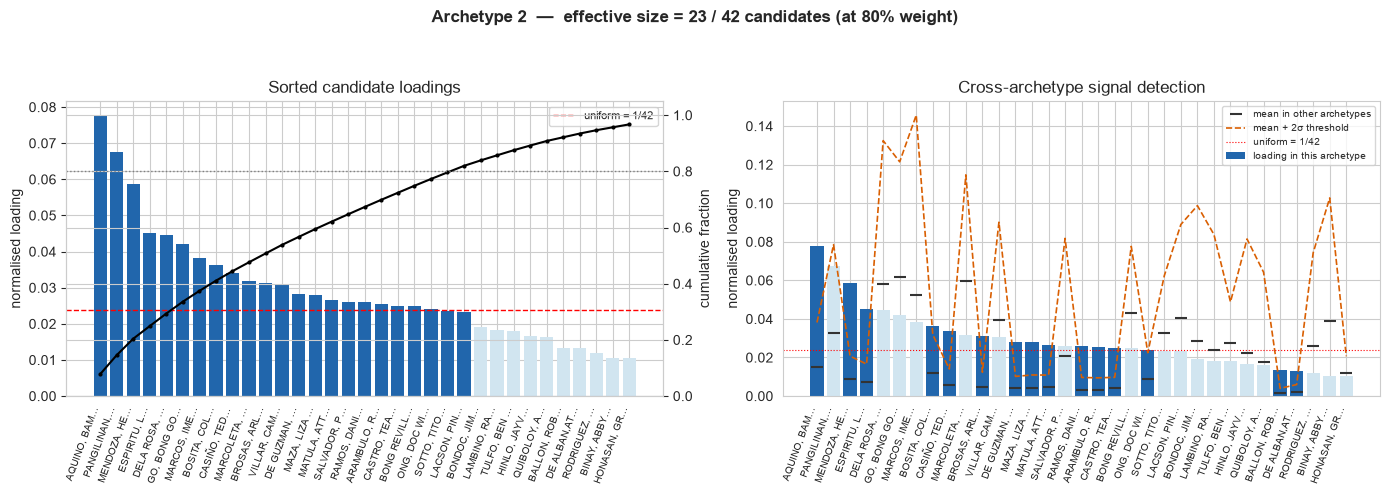

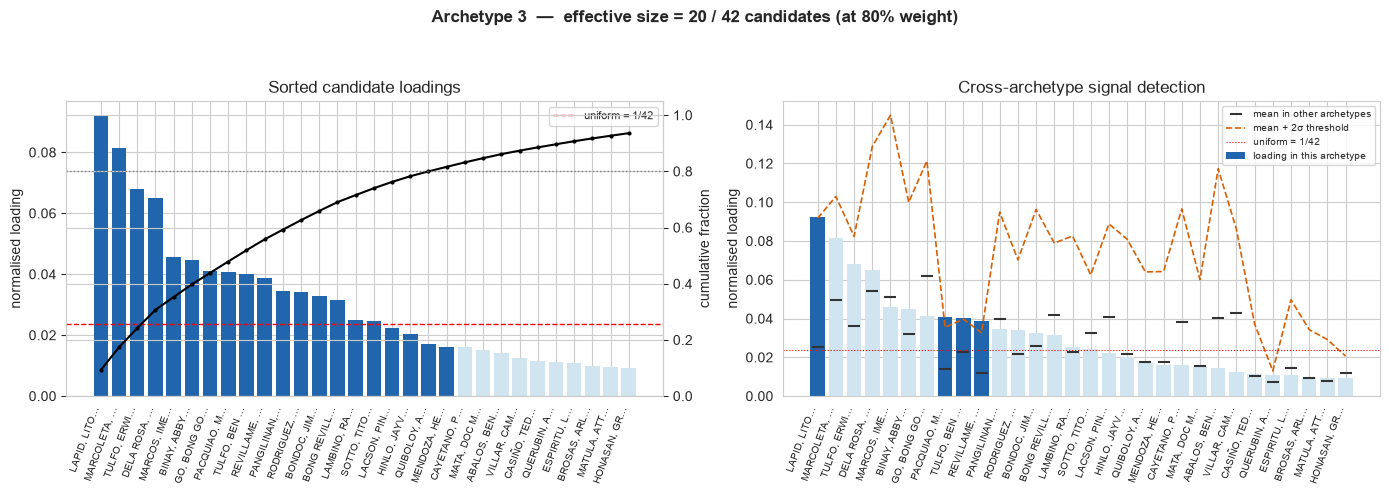

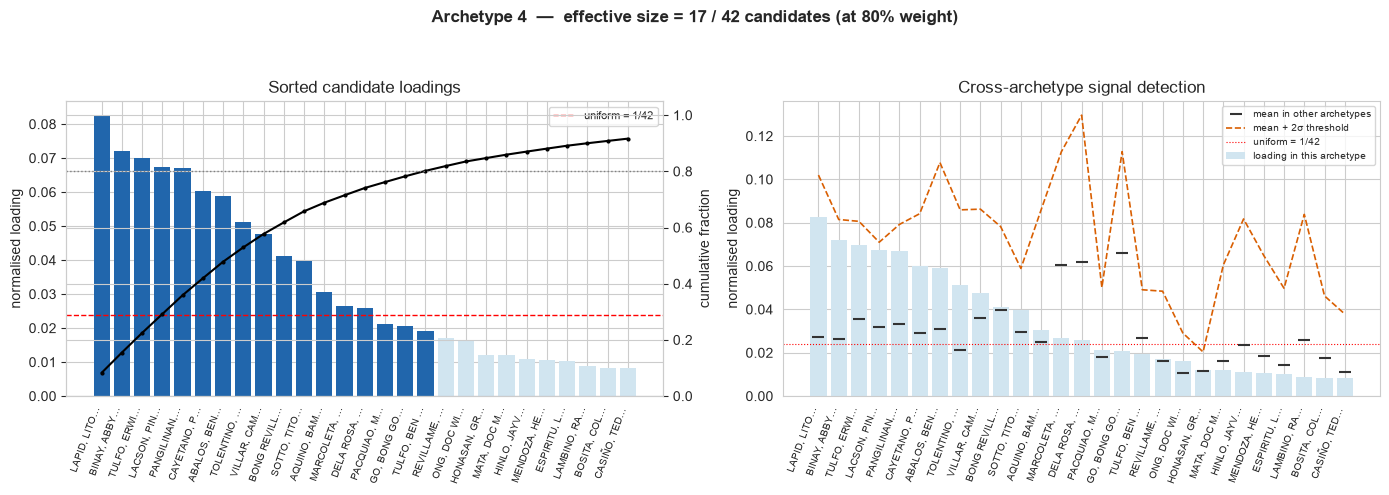

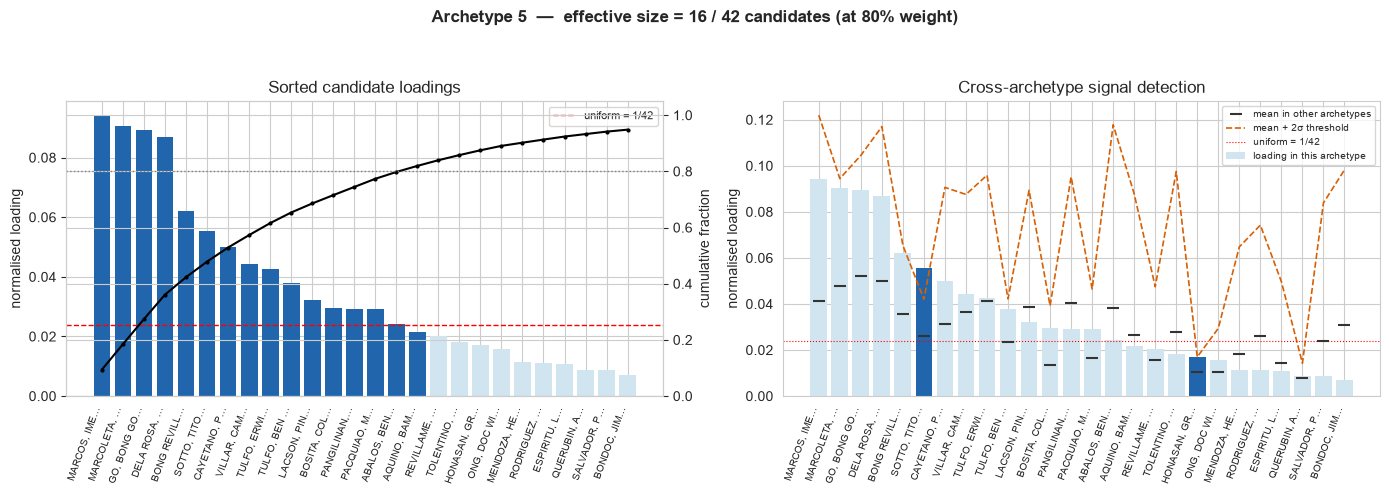

effective archetype sizes: [13 13 23 20 17 16]


In [8]:
from src.unmixing import endmember_noise_floor, abundance_weighted_signal

noise_results = endmember_noise_floor(
    M, candidate_labels=candidate_labels,
    cumulative_threshold=0.80, cross_archetype_sigma=2.0, plot=True)
print('effective archetype sizes:', noise_results['summary'])

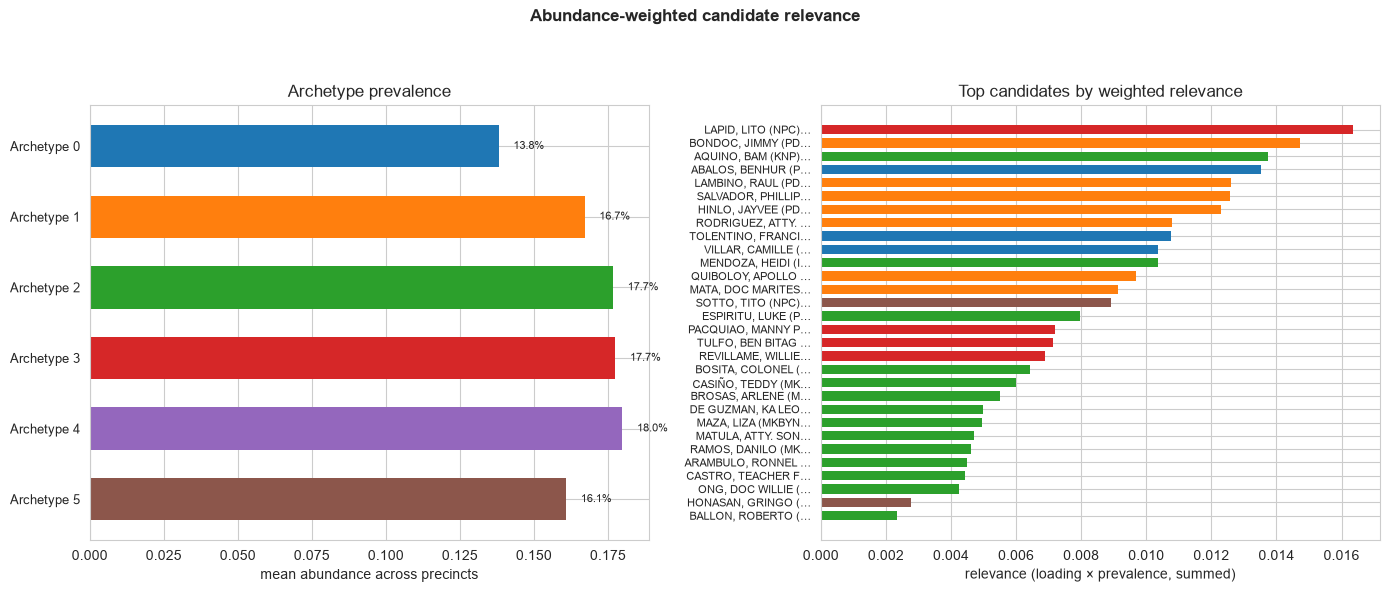

Archetype 0: 13.8%
Archetype 1: 16.7%
Archetype 2: 17.7%
Archetype 3: 17.7%
Archetype 4: 18.0%
Archetype 5: 16.1%


In [9]:
aw = abundance_weighted_signal(noise_results, A,
                               candidate_labels=candidate_labels, plot=True)
for j, prev in enumerate(aw['archetype_prevalence']):
    print(f'Archetype {j}: {prev:.1%}')

## Partylist mixing

In [19]:
def extract_partylist(c_arr):
    p_arr = []
    for i in c_arr:
        try:
            p_arr.append(i.split('(')[1].split(')')[0])
        except IndexError:
            p_arr.append('X')
    return p_arr

In [26]:
df_archtype_partylists = pd.concat(
    [
        pd.DataFrame({
            'candidate': candidate_labels,
            'party': extract_partylist(candidate_labels),
        }, index=None),
        pd.DataFrame(M, columns=[f'Archetype {j}' for j in range(M.shape[1])], index=None)
    ],
    axis=1
)

In [65]:
df_archetype_partylists_sum.melt(id_vars='party', value_vars=[f'Archetype {j}' for j in range(M.shape[1])], var_name='archetype', value_name='loading')

,party,archetype,loading
0,NP,Archetype 0,5.181560
1,PFP,Archetype 0,3.413318
2,NPC,Archetype 0,2.214514
3,PDPLBN,Archetype 0,1.994517
4,LAKAS,Archetype 0,1.921662
...,...,...,...
73,RP,Archetype 5,0.347929
74,MKBYN,Archetype 5,-0.456227
75,PLM,Archetype 5,-0.311615
76,WPP,Archetype 5,-0.084461


In [46]:
df_archetype_partylists_sum = (
    df_archtype_partylists
    .groupby('party')
    .agg(
        {
            "candidate": list,
            **{f'Archetype {j}': 'sum' for j in range(M.shape[1])}
        }
    )
    .sort_values(by=[f'Archetype {j}' for j in range(M.shape[1])], ascending=False)
    .reset_index()
)

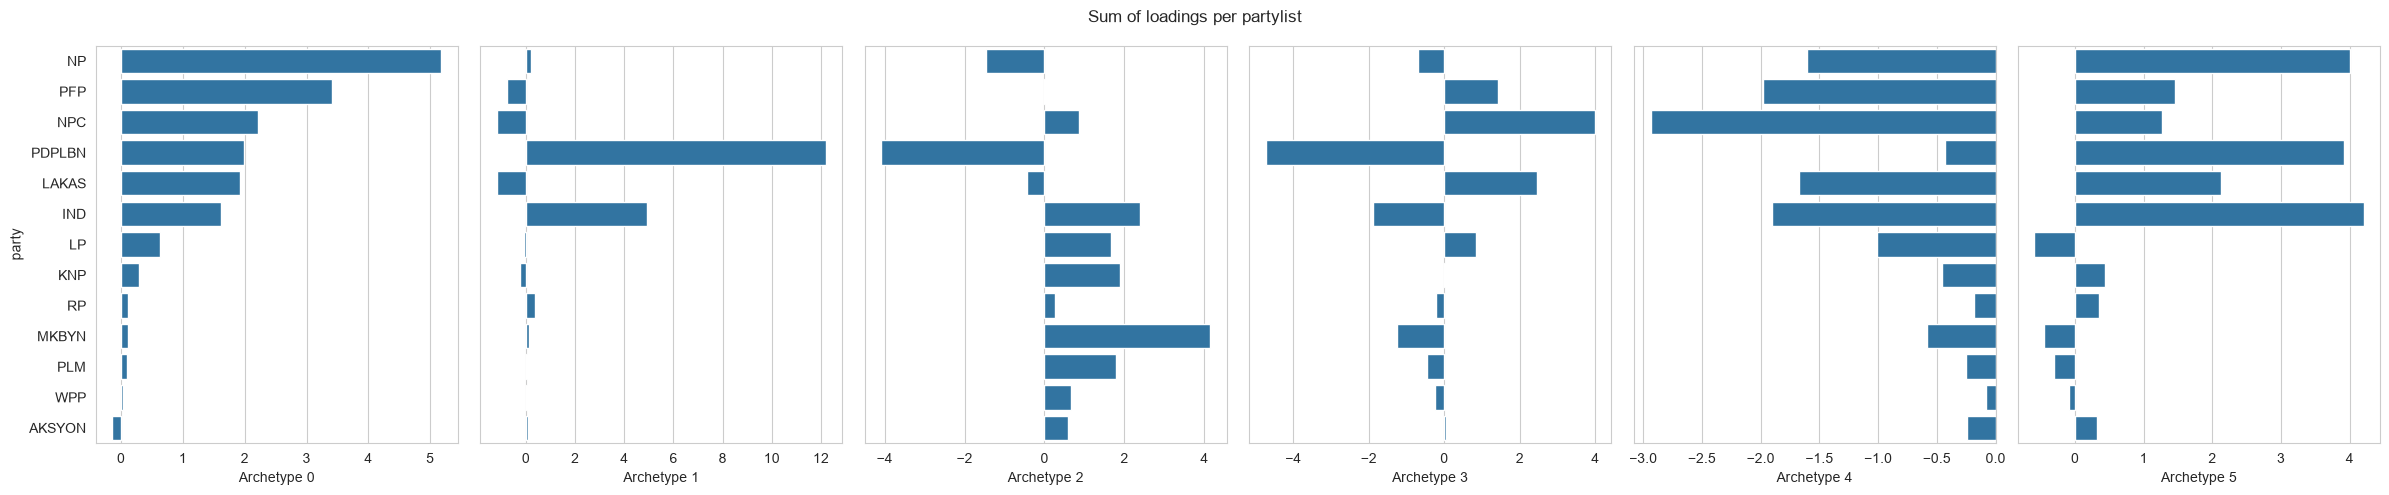

In [63]:
fig, axs = plt.subplots(1, M.shape[1], figsize=(4 * M.shape[1], 5), sharey=True)
for j in range(M.shape[1]):
    sns.barplot(
        data=df_archetype_partylists_sum,#.sort_values(by=f'Archetype {j}', ascending=False),
        y="party",
        x=f"Archetype {j}",
        errorbar=None,
        ax=axs[j]
    )
fig.suptitle("Sum of loadings per partylist")
fig.tight_layout()


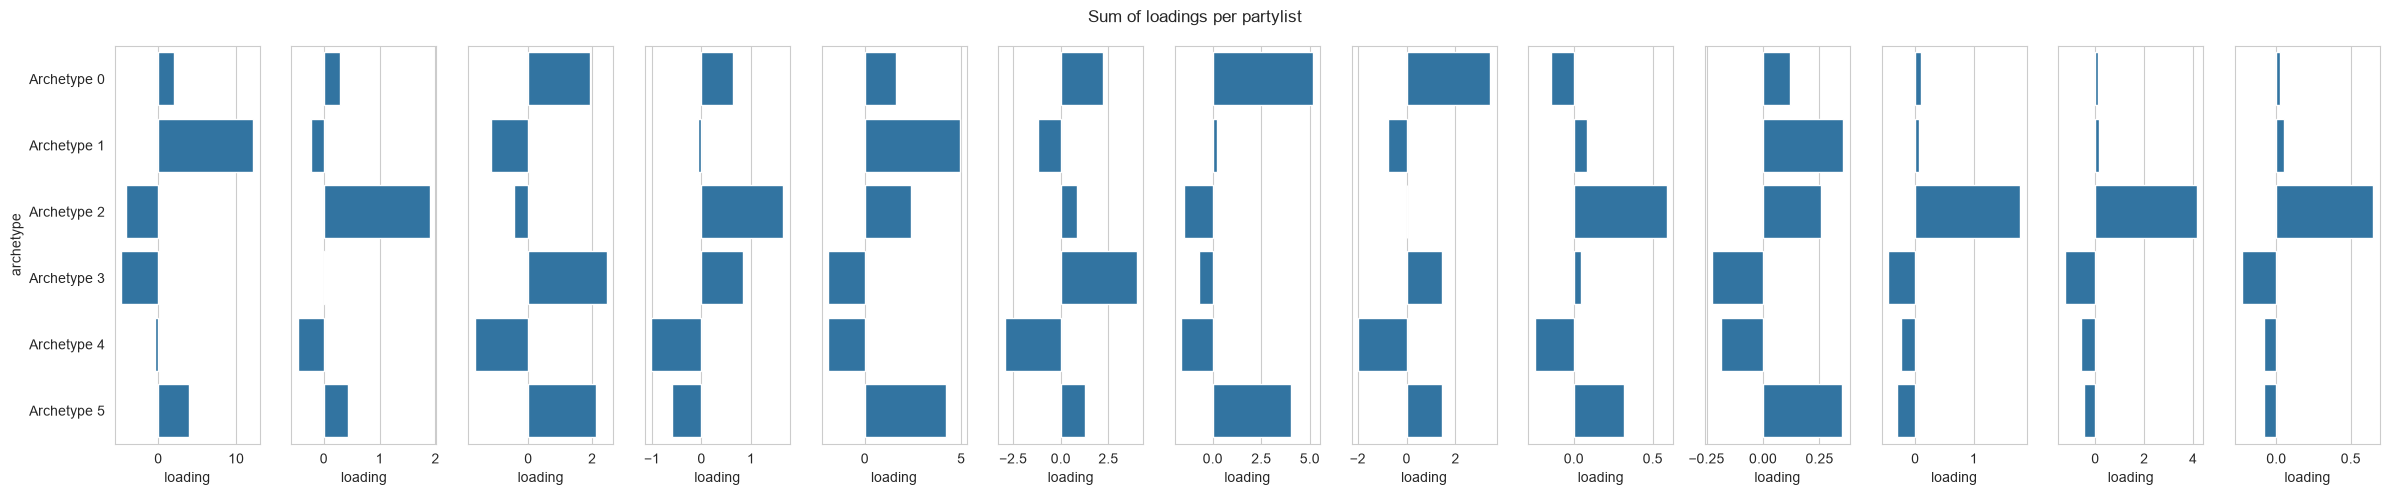

In [69]:

partylists = df_archtype_partylists.party.unique()
fig, axs = plt.subplots(1, len(partylists), figsize=(4 * M.shape[1], 5), sharey=True)

for j in range(len(partylists)):
    sns.barplot(
        data=(
            df_archetype_partylists_sum
            .melt(
                id_vars='party', 
                value_vars=[f'Archetype {j}' for j in range(M.shape[1])], 
                var_name='archetype', value_name='loading')
            ).query(f'party == "{partylists[j]}"'),
        y="archetype",
        x="loading",
        errorbar=None,
        ax=axs[j]
    )
fig.suptitle("Sum of loadings per partylist")
fig.tight_layout()


In [62]:
df_archetype_partylists_sum.iloc[:, :2].explode('candidate').reset_index(drop=True)

,party,candidate
0,NP,"CAYETANO, PIA (NP) [9]"
1,NP,"VILLAR, CAMILLE (NP) [10]"
2,NP,"MARCOS, IMEE R. (NP) [12]"
3,NP,"QUERUBIN, ARIEL PORFIRIO (NP) [37]"
4,PFP,"ABALOS, BENHUR (PFP) [16]"
5,PFP,"PACQUIAO, MANNY PACMAN (PFP) [18]"
6,PFP,"TOLENTINO, FRANCIS TOL (PFP) [25]"
7,NPC,"SOTTO, TITO (NPC) [8]"
8,NPC,"LAPID, LITO (NPC) [11]"
9,NPC,"BINAY, ABBY (NPC) [15]"
